In [19]:
# Cell 1: Feature Extraction Workflow
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from data_loader import DataLoader
from feature_extraction import FeatureExtractor


In [20]:
# Cell 2: Load and Preprocess Data
loader = DataLoader()
X_train, X_val, X_test, y_train, y_val, y_test = loader.prepare_data()

✓ Dataset loaded: 1797 samples, 64 features
✓ Pixels normalized using standard
✓ Data split: Train=1257, Val=180, Test=360


In [13]:
# Cell 3: Initialize Feature Extractor
extractor = FeatureExtractor(image_shape=(8, 8))

In [14]:
# Cell 4: Extract HOG Features
print("\n=== EXTRACTING HOG FEATURES ===")
hog_train = extractor.extract_hog_features(X_train)
hog_val = extractor.extract_hog_features(X_val)
hog_test = extractor.extract_hog_features(X_test)


=== EXTRACTING HOG FEATURES ===
  Processed 500 images for HOG features
  Processed 1000 images for HOG features
✓ HOG features extracted: shape (1257, 324)
✓ HOG features extracted: shape (180, 324)
✓ HOG features extracted: shape (360, 324)


In [15]:
# Cell 5: Extract Pixel Intensity Features
print("\n=== EXTRACTING PIXEL INTENSITY FEATURES ===")
pixel_train = extractor.extract_pixel_intensity(X_train)
pixel_val = extractor.extract_pixel_intensity(X_val)
pixel_test = extractor.extract_pixel_intensity(X_test)



=== EXTRACTING PIXEL INTENSITY FEATURES ===
✓ Pixel intensity features: shape (1257, 64)
✓ Pixel intensity features: shape (180, 64)
✓ Pixel intensity features: shape (360, 64)


In [16]:
# Cell 6: Extract Zernike Moment Features
print("\n=== EXTRACTING ZERNIKE MOMENT FEATURES ===")
zernike_train = extractor.extract_zernike_moments(X_train)
zernike_val = extractor.extract_zernike_moments(X_val)
zernike_test = extractor.extract_zernike_moments(X_test)



=== EXTRACTING ZERNIKE MOMENT FEATURES ===
  Processed 500 images for Zernike moments
  Processed 1000 images for Zernike moments
✓ Zernike moment features extracted: shape (1257, 25)
✓ Zernike moment features extracted: shape (180, 25)
✓ Zernike moment features extracted: shape (360, 25)


In [17]:
# Cell 7: Combine Features
print("\n=== COMBINING FEATURES & APPLYING PCA ===")
features_train = extractor.combine_features(
    hog_train, pixel_train, zernike_train,
    apply_pca=True, n_components=100
)
features_val = extractor.combine_features(
    hog_val, pixel_val, zernike_val,
    apply_pca=False
)
features_test = extractor.combine_features(
    hog_test, pixel_test, zernike_test,
    apply_pca=False
)


=== COMBINING FEATURES & APPLYING PCA ===
✓ Combined features shape: (1257, 413)
✓ PCA applied with 100 components
  Explained variance: 0.9869 (98.69%)
✓ Combined features shape: (180, 413)
✓ Combined features shape: (360, 413)


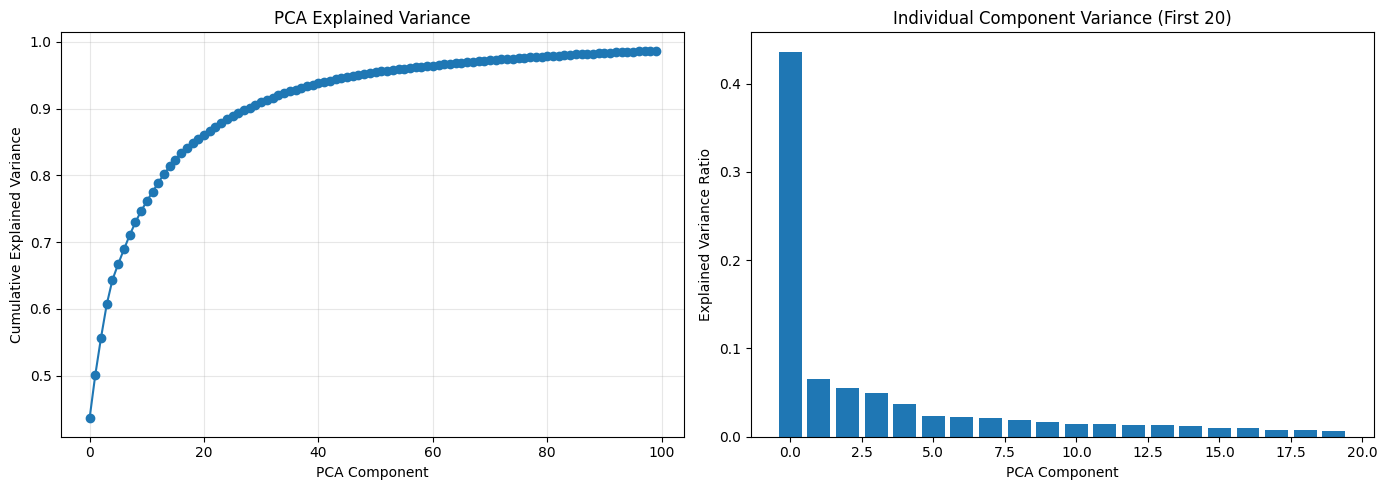


✓ Feature extraction complete!
  Train: (1257, 100)
  Val:   (180, 413)
  Test:  (360, 413)


In [18]:
# Cell 8: Analyze Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot explained variance
axes[0].plot(np.cumsum(extractor.pca.explained_variance_ratio_), 'o-')
axes[0].set_xlabel("PCA Component")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("PCA Explained Variance")
axes[0].grid(True, alpha=0.3)

# Plot individual component variance
axes[1].bar(range(min(20, len(extractor.pca.explained_variance_ratio_))),
            extractor.pca.explained_variance_ratio_[:20])
axes[1].set_xlabel("PCA Component")
axes[1].set_ylabel("Explained Variance Ratio")
axes[1].set_title("Individual Component Variance (First 20)")

plt.tight_layout()
plt.savefig('../data/pca_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✓ Feature extraction complete!")
print(f"  Train: {features_train.shape}")
print(f"  Val:   {features_val.shape}")
print(f"  Test:  {features_test.shape}")
